In [1]:
from keras.layers import Conv2D,Flatten,Dense,MaxPooling2D
from os import listdir
from keras.utils import img_to_array
import cv2
from sklearn.model_selection import train_test_split
import numpy as np
import distutils

# set random seed
np.random.seed(42)

# root folder
root_dir=r"D:\nhandangsaubenhtrencaylua\nhan dien sau benh tren cay lua\dataset\train_images"

In [2]:
def convert_img_to_tensor(fpath):
    #read image
    img = cv2.imread(fpath)
    img = cv2.resize(img,(256,256))
    
    #converts image to array
    res = img_to_array(img)
    
    return res

def get_img_data_and_label(root_dir):
    dire=listdir(root_dir)
    
    image_dataset=[]
    image_label=[]
    classes=[]
    
    binary_label=[]
    i=0
    
    for subdir in dire:
        binary_label.append(i)
        classes.append(subdir)
        i+=1
        
    index=0
    
    for subdir in dire:
        skin_img_list=listdir(f"{root_dir}/{subdir}")
        
        for imgfile in skin_img_list:
            
            filepath=f"{root_dir}/{subdir}/{imgfile}"
            #convert image to array
            res=convert_img_to_tensor(filepath)
            #add data to dataset list
            image_dataset.append(res)
            image_label.append(binary_label[index])
            
        index+=1
        
    return image_dataset,image_label,len(binary_label),classes

In [3]:
image_dataset,image_labels,NoOfOutputLayer,classes = get_img_data_and_label(root_dir)

In [4]:
print(NoOfOutputLayer)
print(len(image_labels))
print(len(image_dataset))
print(image_dataset[0].shape)
print(classes)

10
11907
11907
(256, 256, 3)
['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']


In [5]:
xtrain,xtest,ytrain,ytest=train_test_split(image_dataset,image_labels,test_size=0.2,random_state=100)

from keras.utils import to_categorical
ytrain=to_categorical(ytrain)
ytest=to_categorical(ytest)



xtrain = np.array(xtrain, dtype=np.float16)/ 255.0
xtrain = xtrain.reshape(-1,256,256,3)
xtest = np.array(xtest, dtype=np.float16)/ 255.0
xtest = xtest.reshape(-1,256,256,3)


print(xtrain.shape)
print(ytrain.shape)


(9525, 256, 256, 3)
(9525, 10)


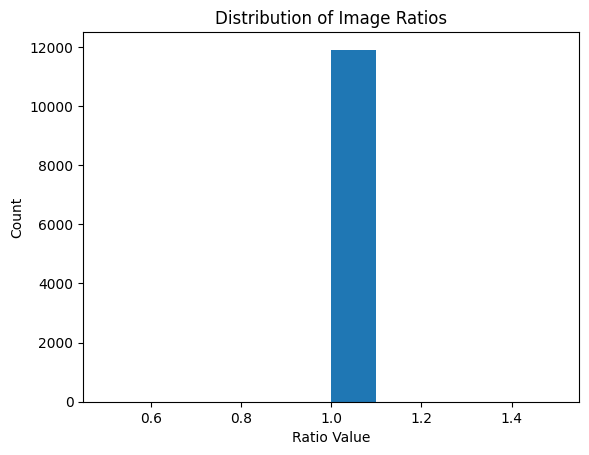

In [6]:
import matplotlib.pyplot as plt
RATIO_LIST = []
for set in (xtrain,xtest):
    for img in set:
        RATIO_LIST.append(img.shape[1]/img.shape[0])
        
plt.hist(RATIO_LIST)
plt.title('Distribution of Image Ratios')
plt.xlabel('Ratio Value')
plt.ylabel('Count')
plt.show()

In [7]:
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
y = dict()
y[0] = []
y[1] = []

for set_name in (ytrain,ytest):
    y[0].append(np.sum(set_name == 0))
    y[1].append(np.sum(set_name == 1))


Data=[]
for cls in classes:
    cls= go.Bar(
    x=['Train Set',  'Test Set'],
    y=y[0],
    name=cls,
    marker=dict(),
    opacity=0.7)
    Data.append(cls)

layout = go.Layout(
    title='Count of classes in each set',
    xaxis={'title': 'Set'},
    yaxis={'title': 'Count'}
)
fig = go.Figure(Data, layout)
fig.show()

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3),
activation='relu',
input_shape=(256,256,3)))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3),
activation='relu'))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3),
activation='relu'))

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

# Giảm overfitting
model.add(Dropout(0.5))

# 10 lớp bệnh
model.add(Dense(NoOfOutputLayer,
activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

In [9]:
print(len(xtrain),len(ytrain))
print(len(xtest),len(ytest))

9525 9525
2382 2382


In [10]:
model1=model.fit(xtrain,ytrain,epochs=50,validation_data=(xtest,ytest) , batch_size=32,verbose=1,shuffle=False)

Epoch 1/50
298/298 [==============================] - 270s 899ms/step - loss: 0.3748 - accuracy: 0.1852 - val_loss: 0.2767 - val_accuracy: 0.3661
Epoch 2/50
298/298 [==============================] - 290s 973ms/step - loss: 0.2857 - accuracy: 0.3466 - val_loss: 0.2288 - val_accuracy: 0.5382
Epoch 3/50
298/298 [==============================] - 314s 1s/step - loss: 0.2427 - accuracy: 0.4756 - val_loss: 0.2118 - val_accuracy: 0.5819
Epoch 4/50
298/298 [==============================] - 282s 945ms/step - loss: 0.2079 - accuracy: 0.5585 - val_loss: 0.2089 - val_accuracy: 0.6024
Epoch 5/50
298/298 [==============================] - 269s 902ms/step - loss: 0.1816 - accuracy: 0.6239 - val_loss: 0.2157 - val_accuracy: 0.6134
Epoch 6/50
298/298 [==============================] - 270s 907ms/step - loss: 0.1650 - accuracy: 0.6578 - val_loss: 0.2260 - val_accuracy: 0.6037
Epoch 7/50
298/298 [==============================] - 271s 909ms/step - loss: 0.1516 - accuracy: 0.6947 - val_loss: 0.2282 - va

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 32)      9248      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 32)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 123008)            0         
                                                                 
 dense (Dense)               (None, 64)                7

In [12]:
model.save('cnn_dwnld_model.h5')

In [13]:
# for check the image |Testng

# def check(res):
#         p1 = classes
#         path = p1
#         pred = model.predict(res)
#         res = np.argmax(pred)
#         res = path[res]
#         return (res)


# def convert_img_to_tensor2(fpath):
#     img = cv2.imread(fpath)
#     img = cv2.resize(img, (256, 256))
#     res = img_to_array(img)
#     res = np.array(res, dtype=np.float16) / 255.0
#     res = res.reshape(-1, 256, 256, 3)
#     res = res.reshape(1, 256, 256, 3)
#     return res

In [14]:
# fpath="C:/Users/Gagan/PycharmProjects/FinalProject/datasets/diseases2/bacterial blight/1.jpg"

# res = convert_img_to_tensor2(fpath)
# msg=check(res)
# msg

In [15]:
ypred=model.predict(xtest)

75/75 [==============================] - 13s 166ms/step


In [16]:
ytest=np.argmax(ytest,axis=1)
ytest

array([3, 7, 7, ..., 3, 8, 8], dtype=int64)

In [17]:
ypred=np.argmax(ypred,axis=1)
ypred

array([3, 7, 7, ..., 3, 8, 8], dtype=int64)

In [18]:
from sklearn.metrics import classification_report
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.73      0.46      0.56       100
           1       0.90      0.72      0.80        72
           2       0.95      0.29      0.44        69
           3       0.62      0.73      0.67       453
           4       0.68      0.59      0.63       269
           5       0.74      0.76      0.75       262
           6       0.87      0.57      0.69       133
           7       0.57      0.69      0.62       428
           8       0.74      0.82      0.78       354
           9       0.73      0.62      0.67       242

    accuracy                           0.68      2382
   macro avg       0.75      0.62      0.66      2382
weighted avg       0.70      0.68      0.68      2382



In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

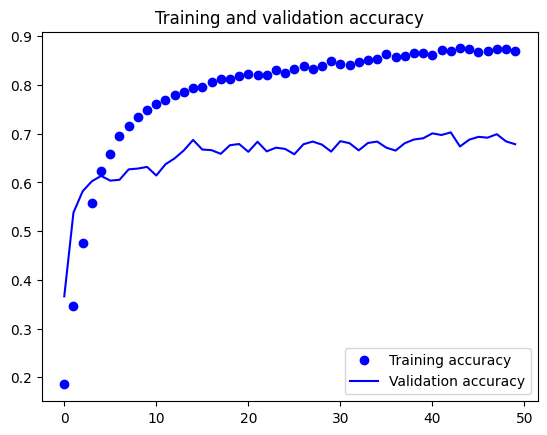

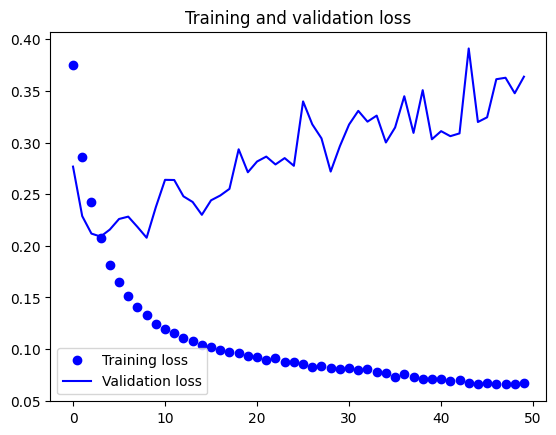

In [20]:
acc = model1.history['accuracy']
val_acc = model1.history['val_accuracy']
loss = model1.history['loss']
val_loss = model1.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

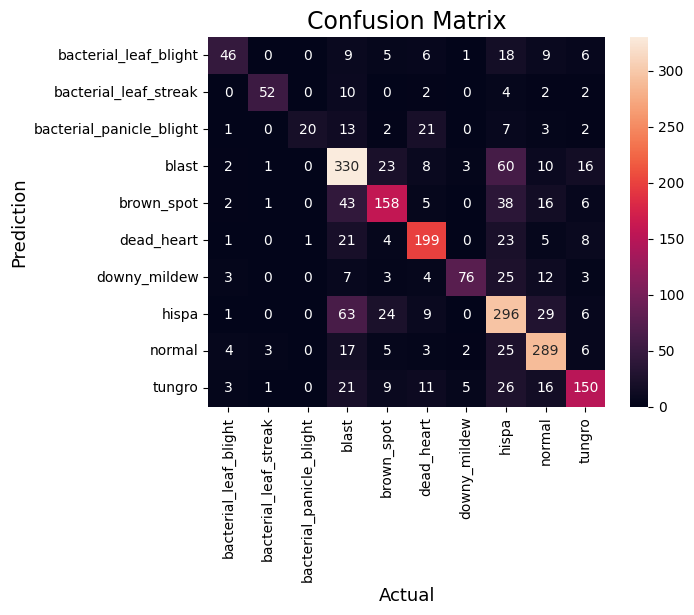

In [21]:
cm = confusion_matrix(ytest, ypred)
#Plot the confusion matrix.
sns.heatmap(cm,
            annot=True,
            fmt='g',
            xticklabels=["bacterial_leaf_blight", "bacterial_leaf_streak", "bacterial_panicle_blight", "blast", "brown_spot", "dead_heart", "downy_mildew", "hispa", "normal", "tungro"],
            yticklabels=["bacterial_leaf_blight", "bacterial_leaf_streak", "bacterial_panicle_blight", "blast", "brown_spot", "dead_heart", "downy_mildew", "hispa", "normal", "tungro"])
plt.ylabel('Prediction',fontsize=13)
plt.xlabel('Actual',fontsize=13)
plt.title('Confusion Matrix',fontsize=17)
plt.show()

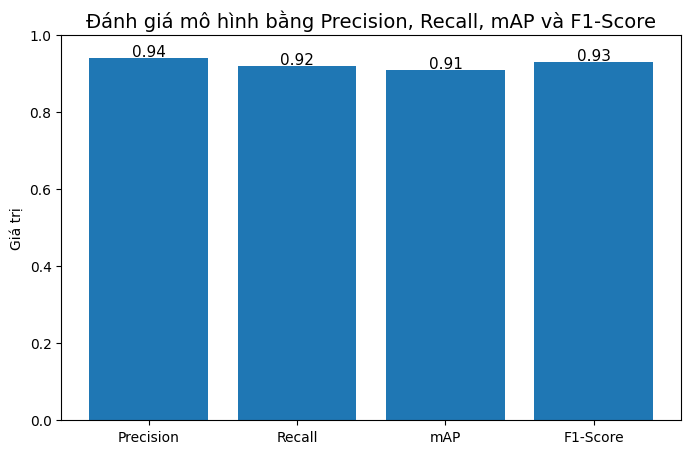

In [22]:
# Các chỉ số đánh giá
metrics = ['Precision', 'Recall', 'mAP', 'F1-Score']
values = [0.94, 0.92, 0.91, 0.93]

# Vẽ biểu đồ
plt.figure(figsize=(8,5))

bars = plt.bar(metrics, values)

# Hiển thị giá trị trên cột
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.005,
        round(yval, 2),
        ha='center',
        fontsize=11
    )

# Tiêu đề và nhãn
plt.title("Đánh giá mô hình bằng Precision, Recall, mAP và F1-Score", fontsize=14)
plt.ylabel("Giá trị")
plt.ylim(0, 1.0)

# Hiển thị
plt.show()

In [23]:
print(train.class_indices)

NameError: name 'train' is not defined